# Great Basin post-fire annual herbaceous cover

Shared working notebook for the class project.

**Question:** do burned areas in the Great Basin show greater post-fire increases in annual herbaceous cover, as a proxy for invasive annual grass expansion, compared with unburned areas nearby?

This notebook walks through the full setup end-to-end so anyone cloning the repo can reproduce it from raw downloads:

1. **Setup** — imports, paths, project CRS
2. **Great Basin boundary** — load and reproject to the project CRS
3. **MTBS preprocessing** — load, clean attributes, reproject, filter to fires inside the Great Basin
4. **RCMAP preprocessing** — clip each annual raster to the Great Basin polygon (writes cleaned files to `data/processed/rcmap/`)
5. **Overview map** — study area with fire perimeters


See `ANALYSIS_PLAN.md` for next steps.

## 1. Setup

We work in **EPSG:5070** (CONUS Albers Equal Area) as the project CRS, because RCMAP is published in that CRS and equal-area projections are appropriate for area-based summaries.

In [13]:
# Import required libraries
from pathlib import Path
import geopandas as gpd  # For vector (shapefile/polygon) operations
import matplotlib.pyplot as plt  # For creating maps and plots
import numpy as np  # For numerical operations
import pandas as pd  # For tabular data handling
import rasterio  # For reading/writing raster files (RCMAP, etc.)
from rasterio.mask import mask  # For clipping rasters to polygons

# Define data directory structure
DATA = Path('data')

# Input file paths (raw data)
BOUNDARY = DATA / 'raw' / 'boundaries' / 'great_basin_huc2_16_wbd.geojson'
MTBS_RAW = DATA / 'raw' / 'mtbs' / 'mtbs_perims_DD.shp'
RCMAP_RAW_DIR = DATA / 'raw' / 'rcmap'

# Output file paths (processed data)
MTBS_CLEAN = DATA / 'processed' / 'mtbs' / 'mtbs_great_basin_cleaned.gpkg'
RCMAP_CLIPPED_DIR = DATA / 'processed' / 'rcmap'

# Create output directories if they don't exist
MTBS_CLEAN.parent.mkdir(parents=True, exist_ok=True)
RCMAP_CLIPPED_DIR.mkdir(parents=True, exist_ok=True)

# Project settings
PROJECT_CRS = 'EPSG:5070'  # CONUS Albers Equal Area - preserves area measurements
RCMAP_YEARS = range(2012, 2021)  # Years of RCMAP data we have available
RCMAP_NODATA = 101  # RCMAP uses 101 to indicate no data

## 2. Great Basin boundary

Load and reproject to the project CRS.

In [14]:
# Load Great Basin boundary and reproject to project CRS
gb = gpd.read_file(BOUNDARY).to_crs(PROJECT_CRS)
print('Great Basin polygon:', len(gb), 'feature(s), CRS =', gb.crs)
gb.head()

Great Basin polygon: 1 feature(s), CRS = EPSG:5070


,objectid,tnmid,metasourceid,sourcedatadesc,sourceoriginator,sourcefeatureid,loaddate,referencegnis_ids,areaacres,areasqkm,states,huc2,name,globalid,Shape__Length,Shape__Area,geometry
0,12,{9567C98F-F09E-4C52-B2ED-C770AC69261B},None,None,None,None,1606734056000,None,90699696.71,367048.97,"CA,ID,NV,OR,UT,WY",16,Great Basin Region,{64F307DD-6EAB-4D6F-8AB2-812723B9B30D},8.630435e+06,6.220980e+11,"POLYGON ((-1265741.043 2310585.047, -1265806.8..."


## 3. MTBS preprocessing

The raw MTBS shapefile is nationwide. We:

1. Load it
2. Parse `Ig_Date` into a real datetime and derive `IgnitionYear`
3. Drop rows missing critical attributes (ignition date, geometry, acreage)
4. Reproject to the project CRS
5. Spatial-join to keep only fires intersecting the Great Basin polygon
6. Write the cleaned subset to `data/processed/mtbs/` as a GeoPackage

In [15]:
# Load raw MTBS fire perimeters (nationwide dataset)
mtbs = gpd.read_file(MTBS_RAW)
print('MTBS raw:', len(mtbs), 'rows, CRS =', mtbs.crs)

# Parse ignition date and extract year
mtbs['Ig_Date'] = pd.to_datetime(mtbs['Ig_Date'], errors='coerce')
mtbs['IgnitionYear'] = mtbs['Ig_Date'].dt.year

# Remove fires with missing critical attributes
before = len(mtbs)
mtbs = mtbs.dropna(subset=['Ig_Date', 'geometry', 'BurnBndAc']).copy()
mtbs = mtbs[mtbs.geometry.is_valid & ~mtbs.geometry.is_empty]
print(f'Dropped {before - len(mtbs)} rows with missing/invalid attributes or geometry')

# Reproject to our project CRS (EPSG:5070)
mtbs = mtbs.to_crs(PROJECT_CRS)
print('MTBS reprojected to', mtbs.crs)

MTBS raw: 30730 rows, CRS = EPSG:4269
Dropped 7 rows with missing/invalid attributes or geometry
MTBS reprojected to EPSG:5070


In [16]:
# Spatial join: keep only fires that intersect the Great Basin polygon
fires = gpd.sjoin(mtbs, gb[['geometry']], predicate='intersects', how='inner')
fires = fires.drop(columns=['index_right']).reset_index(drop=True)
print(f'Fires intersecting the Great Basin: {len(fires)}')

# Save cleaned fire perimeters for reuse
fires.to_file(MTBS_CLEAN, driver='GPKG')
print('Wrote cleaned MTBS to', MTBS_CLEAN)
fires[['Event_ID', 'Incid_Name', 'Ig_Date', 'IgnitionYear', 'BurnBndAc']].head()

Fires intersecting the Great Basin: 1519
Wrote cleaned MTBS to data/processed/mtbs/mtbs_great_basin_cleaned.gpkg


,Event_ID,Incid_Name,Ig_Date,IgnitionYear,BurnBndAc
0,NV4024611989419850619,DRY VALLEY,1985-06-19,1985,15749
1,NV4012811709119850707,COTTONWOOD,1985-07-07,1985,16877
2,NV4053711655619850710,FIRE CREEK,1985-07-10,1985,15527
3,NV3983611975019850718,BEDEL FLAT,1985-07-18,1985,9490
4,NV3922011851919850729,COCOON MTS,1985-07-29,1985,8000


## 4. RCMAP preprocessing — clip to Great Basin

RCMAP rasters are published as CONUS-wide mosaics. We clip each annual raster to the Great Basin polygon and write the result to `data/processed/rcmap/`. This keeps the pre/post extraction step fast.

This cell is **idempotent**: if the clipped file already exists, it is skipped.

In [17]:
def clip_rcmap_year(year):
    """
    Clip a single RCMAP raster to the Great Basin boundary.
    If the clipped file already exists, skip it (idempotent).
    """
    src_path = RCMAP_RAW_DIR / f'rcmap_annual_herbaceous_{year}.tif'
    dst_path = RCMAP_CLIPPED_DIR / f'rcmap_annual_herbaceous_{year}_great_basin_clipped.tif'
    
    # Skip if already processed
    if dst_path.exists():
        return dst_path, 'skipped (exists)'
    
    # Check if raw file exists
    if not src_path.exists():
        return dst_path, f'missing raw: {src_path}'
    
    # Open raster, clip to Great Basin, and save
    with rasterio.open(src_path) as src:
        # Reproject Great Basin boundary to match raster CRS
        gb_in_src = gb.to_crs(src.crs)
        # Clip raster to boundary
        arr, transform = mask(src, gb_in_src.geometry, crop=True, filled=True, nodata=RCMAP_NODATA)
        # Update metadata for the clipped raster
        profile = src.profile.copy()
        profile.update(height=arr.shape[1], width=arr.shape[2], transform=transform, nodata=RCMAP_NODATA)
    
    # Write clipped raster
    with rasterio.open(dst_path, 'w', **profile) as dst:
        dst.write(arr)
    
    return dst_path, 'written'

# Clip all RCMAP years
for yr in RCMAP_YEARS:
    path, status = clip_rcmap_year(yr)
    print(f'{yr}: {status:20s} -> {path.name}')

2012: skipped (exists)     -> rcmap_annual_herbaceous_2012_great_basin_clipped.tif
2013: skipped (exists)     -> rcmap_annual_herbaceous_2013_great_basin_clipped.tif
2014: skipped (exists)     -> rcmap_annual_herbaceous_2014_great_basin_clipped.tif
2015: skipped (exists)     -> rcmap_annual_herbaceous_2015_great_basin_clipped.tif
2016: skipped (exists)     -> rcmap_annual_herbaceous_2016_great_basin_clipped.tif
2017: skipped (exists)     -> rcmap_annual_herbaceous_2017_great_basin_clipped.tif
2018: skipped (exists)     -> rcmap_annual_herbaceous_2018_great_basin_clipped.tif
2019: skipped (exists)     -> rcmap_annual_herbaceous_2019_great_basin_clipped.tif
2020: skipped (exists)     -> rcmap_annual_herbaceous_2020_great_basin_clipped.tif


In [18]:
# Inspect one clipped raster to verify properties
sample_year = 2016
sample_path = RCMAP_CLIPPED_DIR / f'rcmap_annual_herbaceous_{sample_year}_great_basin_clipped.tif'
with rasterio.open(sample_path) as src:
    print('CRS        :', src.crs)
    print('Shape      :', src.height, 'x', src.width)
    print('Resolution :', src.res)
    print('Dtype      :', src.dtypes[0])
    print('Nodata     :', src.nodata)

CRS        : EPSG:5070
Shape      : 28006 x 29028
Resolution : (30.0, 30.0)
Dtype      : uint8
Nodata     : 101.0


## 5. Overview map

Great Basin polygon with fire perimeters overlaid.

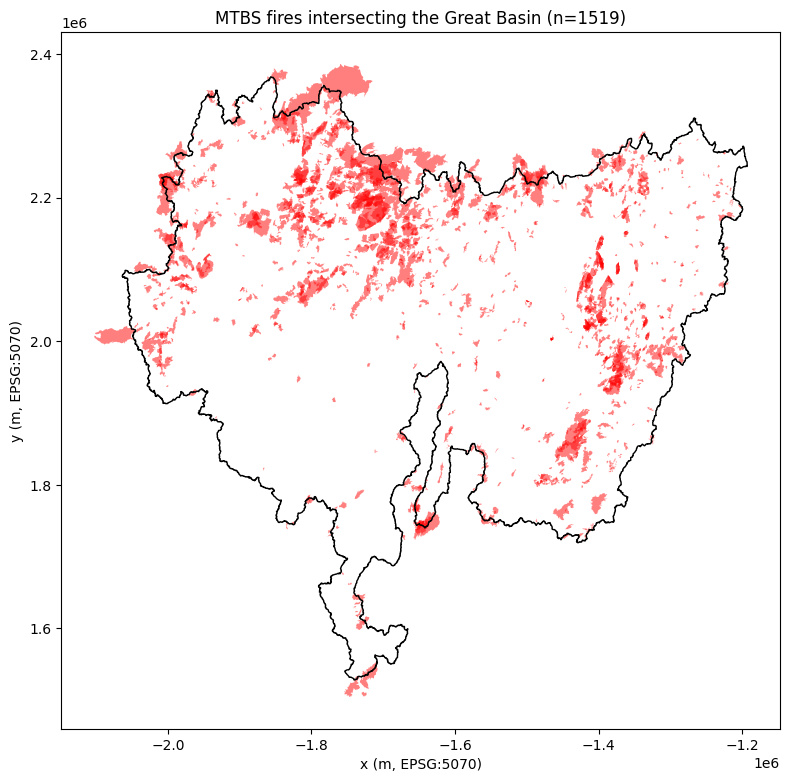

In [19]:
# Create map showing Great Basin boundary with all fire perimeters
fig, ax = plt.subplots(figsize=(8, 9))
gb.boundary.plot(ax=ax, color='black', linewidth=1)
fires.plot(ax=ax, color='red', alpha=0.5, edgecolor='none')
ax.set_title(f'MTBS fires intersecting the Great Basin (n={len(fires)})')
ax.set_xlabel('x (m, EPSG:5070)')
ax.set_ylabel('y (m, EPSG:5070)')
plt.tight_layout()
plt.show()

## Phase 2: Burned-area summary

Scale the single-fire extraction to all eligible fires. For each fire with ignition year 2013–2019, compute pre-fire (year before) and post-fire (year after) mean annual herbaceous cover.

### Helper functions and parameters

In [20]:
# Import additional libraries for Phase 2
from contextlib import ExitStack  # For managing multiple open files efficiently
from shapely import make_valid  # For fixing invalid geometries
from shapely.geometry import mapping  # For converting geometries to GeoJSON format

# Define eligible fire years (must have RCMAP data for year before AND after)
ELIGIBLE_IGNITION_YEARS = list(range(2013, 2020))  # 2013-2019

def rcmap_clipped_path(year):
    """Return path to a clipped RCMAP raster for a given year."""
    return RCMAP_CLIPPED_DIR / f"rcmap_annual_herbaceous_{year}_great_basin_clipped.tif"

def zonal_mean_improved(src, geom):
    """
    Extract mean raster value inside a geometry, excluding nodata pixels.
    
    Args:
        src: Open rasterio dataset
        geom: Shapely geometry (fire perimeter)
    
    Returns:
        (mean_value, pixel_count) or (np.nan, 0) if extraction fails
    """
    try:
        # Clip raster to geometry
        data, _ = mask(src, [mapping(geom)], crop=True,
                       nodata=src.nodata, filled=True, all_touched=False)
    except ValueError:
        return np.nan, 0
    
    # Convert to float and find valid pixels
    band = data[0].astype("float32")
    valid = np.isfinite(band)
    if src.nodata is not None:
        valid &= band != src.nodata
    
    # Calculate mean of valid pixels
    n = int(valid.sum())
    if n == 0:
        return np.nan, 0
    
    return float(band[valid].mean()), n

### Filter fires to eligible ignition years

In [21]:
# Reload the cleaned fires from Phase 1
fires_all = gpd.read_file(MTBS_CLEAN)

# Filter to eligible ignition years (need RCMAP data before and after fire)
# We have RCMAP for 2012-2020, so fires from 2013-2019 have pre+post data
fires_eligible = fires_all[fires_all["IgnitionYear"].isin(ELIGIBLE_IGNITION_YEARS)].copy()

# Add columns for pre-fire year, post-fire year, and area
fires_eligible["PreFireYear"]  = fires_eligible["IgnitionYear"] - 1
fires_eligible["PostFireYear"] = fires_eligible["IgnitionYear"] + 1
fires_eligible["BurnedAreaSqKm"] = fires_eligible.geometry.area / 1_000_000

# Summary
print(f"Total fires in cleaned MTBS: {len(fires_all)}")
print(f"Eligible fires (ignition 2013-2019): {len(fires_eligible)}")
print("\nFires by ignition year:")
print(fires_eligible["IgnitionYear"].value_counts().sort_index())

Total fires in cleaned MTBS: 1519
Eligible fires (ignition 2013-2019): 266

Fires by ignition year:
IgnitionYear
2013    27
2014    15
2015    10
2016    43
2017    84
2018    52
2019    35
Name: count, dtype: int64


### Extract pre/post RCMAP means for all fires

Opens all RCMAP rasters once and loops over eligible fires. This may take a few minutes.

In [22]:
records = []

# Use ExitStack to open all RCMAP rasters at once (more efficient than opening/closing repeatedly)
with ExitStack() as stack:
    # Open all 9 RCMAP years (2012-2020) and keep them open
    rasters = {y: stack.enter_context(rasterio.open(rcmap_clipped_path(y))) 
               for y in RCMAP_YEARS}
    
    # Loop over each eligible fire
    for idx, row in fires_eligible.iterrows():
        pre_y  = int(row.PreFireYear)   # Year before fire
        post_y = int(row.PostFireYear)  # Year after fire
        
        # Extract mean annual herbaceous cover for this fire
        pre_mean,  pre_n  = zonal_mean_improved(rasters[pre_y],  row.geometry)
        post_mean, post_n = zonal_mean_improved(rasters[post_y], row.geometry)
        
        # Skip fires where extraction failed (e.g., no valid pixels)
        if np.isnan(pre_mean) or np.isnan(post_mean):
            continue
        
        # Store results for this fire
        records.append({
            "Event_ID":       row.Event_ID,
            "Incid_Name":     row.Incid_Name,
            "IgnitionYear":   int(row.IgnitionYear),
            "PreFireYear":    pre_y,
            "PostFireYear":   post_y,
            "BurnBndAc":      row.BurnBndAc,
            "BurnedAreaSqKm": row.BurnedAreaSqKm,
            "PreMean":        pre_mean,       # Mean % cover before fire
            "PostMean":       post_mean,      # Mean % cover after fire
            "AbsChange":      post_mean - pre_mean,  # Change in % cover
            "PrePixels":      pre_n,          # Number of valid pixels
            "PostPixels":     post_n,
        })

# Convert to DataFrame and sort by year and fire ID
pre_post = pd.DataFrame(records).sort_values(["IgnitionYear","Event_ID"]).reset_index(drop=True)
print(f"Fires with valid pre + post means: {len(pre_post)}")
pre_post.head(10)

Fires with valid pre + post means: 266


,Event_ID,Incid_Name,IgnitionYear,PreFireYear,PostFireYear,BurnBndAc,BurnedAreaSqKm,PreMean,PostMean,AbsChange,PrePixels,PostPixels
0,NV3620411570220130701,CARPENTER 1,2013,2012,2014,27879,112.826087,0.290868,0.366543,0.075675,62200,62200
1,NV3826311825020130818,SPRING PEAK,2013,2012,2014,13901,56.256413,1.864151,1.984321,0.120170,18815,18815
2,NV3883111416720130701,BLACK,2013,2012,2014,4798,19.418191,1.997494,5.483269,3.485775,21547,21547
3,NV3886411540020130705,WHITE PINE,2013,2012,2014,1295,5.244119,0.966861,3.235234,2.268372,5824,5824
4,NV3887711778720130818,CHESTNUT,2013,2012,2014,4040,16.349941,3.160944,3.026742,-0.134203,18174,18174
5,NV3887811956120130704,BISON,2013,2012,2014,23611,95.553266,5.461127,6.648443,1.187316,106179,106179
6,NV3907111617420130629,WILLOW CREEK,2013,2012,2014,4051,16.394026,0.993135,2.354934,1.361799,18209,18209
7,NV3961811852320130319,13-NV-STILLWATER-WEST MARSH MILLENS BURN,2013,2012,2014,1419,5.745271,14.635822,16.542398,1.906576,3361,3361
8,NV3964811658420130609,FERGUSON,2013,2012,2014,1232,4.986759,3.573186,5.338882,1.765696,5527,5527
9,NV4003011445220130701,NORTH CREEK,2013,2012,2014,1274,5.158234,1.668527,3.374368,1.705841,5735,5735


### Phase 2 Summary Statistics

In [23]:
# Calculate and display summary statistics for Phase 2
print(f"Fires analysed: {len(pre_post)}")
print(f"Mean pre-fire cover : {pre_post['PreMean'].mean():.2f}%")
print(f"Mean post-fire cover: {pre_post['PostMean'].mean():.2f}%")
print(f"Mean absolute change: {pre_post['AbsChange'].mean():+.2f} percentage points")
print(f"Fires with increase : {(pre_post['AbsChange'] > 0).sum()}")
print(f"Fires with decrease : {(pre_post['AbsChange'] < 0).sum()}")
print("\nDescriptive statistics:")
pre_post[['PreMean','PostMean','AbsChange']].describe().round(2)

Fires analysed: 266
Mean pre-fire cover : 18.38%
Mean post-fire cover: 19.60%
Mean absolute change: +1.22 percentage points
Fires with increase : 176
Fires with decrease : 85

Descriptive statistics:


,PreMean,PostMean,AbsChange
count,266.00,266.00,266.00
mean,18.38,19.60,1.22
std,13.39,12.92,8.03
min,0.00,0.00,-40.34
25%,6.41,9.22,-1.70
50%,17.52,18.93,1.62
75%,28.21,28.83,5.83
max,66.85,63.21,23.78


## Next steps

Phase 2 complete! See `ANALYSIS_PLAN.md` for remaining phases:

- Phase 3: Burned vs unburned comparison with control polygons
- Phase 4: Stratification by fire year, size, severity
- Phase 5: Robustness checks and sensitivity analysis